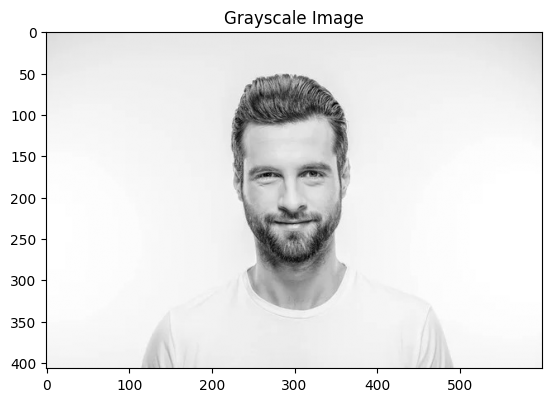

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE1 = 'adult.jpeg'
TARGET_IMAGE = 'messi.jpeg'

#image source
img = cv2.imread(IMAGE1)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.show()

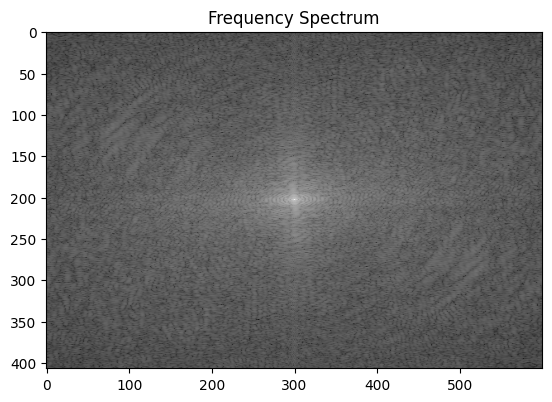

In [50]:
#applying fft
f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)

# magnitude spectrum
magnitude_spectrum = 20*np.log(np.abs(fshift)+1)

plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Frequency Spectrum")
plt.show()

In [51]:
rows, cols = gray.shape
crow, ccol = rows//2 , cols//2

# filter lower frequncies out
mask = np.ones((rows, cols), np.uint8)
r = 30                                    # radius for low freq removal
mask[crow-r:crow+r, ccol-r:ccol+r] = 0

# apply mask
fshift_filtered = fshift * mask

high_freq_energy = np.sum(np.abs(fshift_filtered))
print("High Frequency Energy:", high_freq_energy)

High Frequency Energy: 634486980.2644638


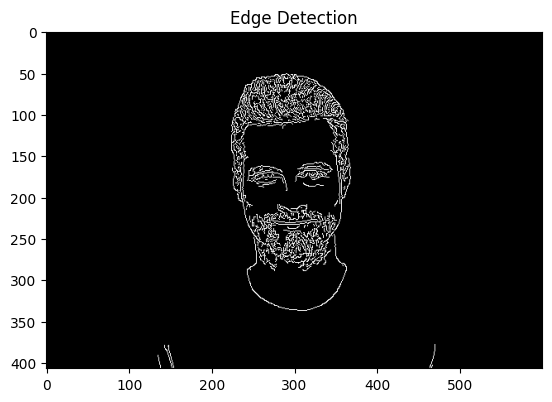

Edge Density: 6.522235872235872


In [52]:
edges = cv2.Canny(gray, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.show()

edge_density = np.sum(edges) / (gray.shape[0]*gray.shape[1])
print("Edge Density:", edge_density)

In [53]:
print("\n--- Starting Face Swap Pipeline ---")

# setup dlib tools
import dlib
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# define image
img_source = img 
img_source_gray = cv2.cvtColor(img_source, cv2.COLOR_BGR2GRAY)

# target image loading

img_target = cv2.imread(TARGET_IMAGE) 
if img_target is None:
    print("Error: Target image not found!")
else:
    img_target_gray = cv2.cvtColor(img_target, cv2.COLOR_BGR2GRAY)

    # detect landmarks for both the face
    def get_landmarks(image_gray):
        faces = detector(image_gray)
        if len(faces) == 0:
            return None
        # we assume the first face found is the one we select
        return predictor(image_gray, faces[0])

    landmarks_source = get_landmarks(img_source_gray)
    landmarks_target = get_landmarks(img_target_gray)

    if landmarks_source and landmarks_target:
        print("Success: Landmarks detected in both images.")
        # proceed with triangulation
    else:
        print("Error: Could not find a face in one of the images.")


--- Starting Face Swap Pipeline ---
Success: Landmarks detected in both images.


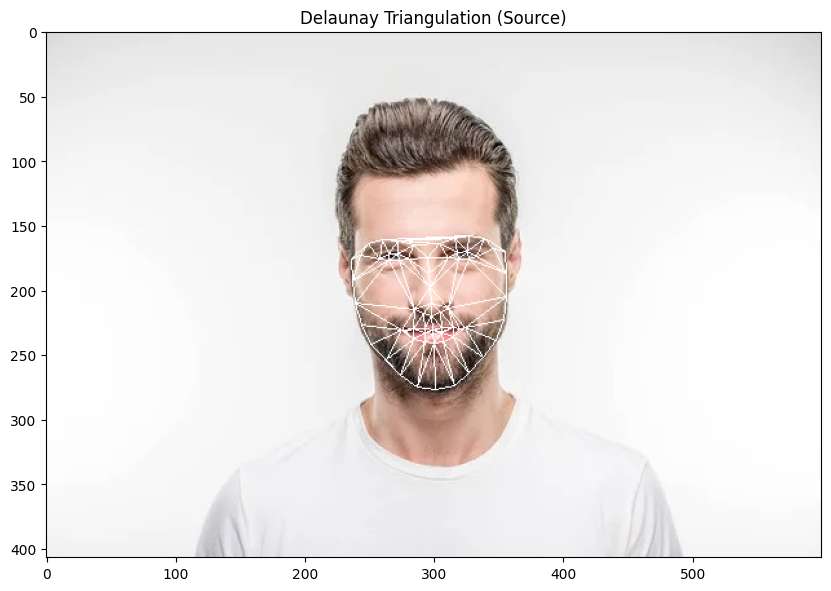

Generated 110 triangles.


In [54]:
from scipy.spatial import Delaunay
import numpy as np

# coords for all the generated triangles
def extract_points(landmarks):
    points = []
    for i in range(68):
        point = (landmarks.part(i).x, landmarks.part(i).y)
        points.append(point)
    return np.array(points)

points_source = extract_points(landmarks_source)
points_target = extract_points(landmarks_target)

# delauny triangulation on the source
# calcuation of this first before applying.
tri = Delaunay(points_source)
triangle_indexes = tri.simplices

# 3. triangulation output
img_source_triangulated = img_source.copy()

for triangle_index in triangle_indexes:
    # corners of triangle
    pt1 = points_source[triangle_index[0]]
    pt2 = points_source[triangle_index[1]]
    pt3 = points_source[triangle_index[2]]
    
    # connect the traingles
    cv2.line(img_source_triangulated, tuple(pt1), tuple(pt2), (255, 255, 255), 1)
    cv2.line(img_source_triangulated, tuple(pt2), tuple(pt3), (255, 255, 255), 1)
    cv2.line(img_source_triangulated, tuple(pt3), tuple(pt1), (255, 255, 255), 1)

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img_source_triangulated, cv2.COLOR_BGR2RGB))
plt.title("Delaunay Triangulation (Source)")
plt.show()

print(f"Generated {len(triangle_indexes)} triangles.")

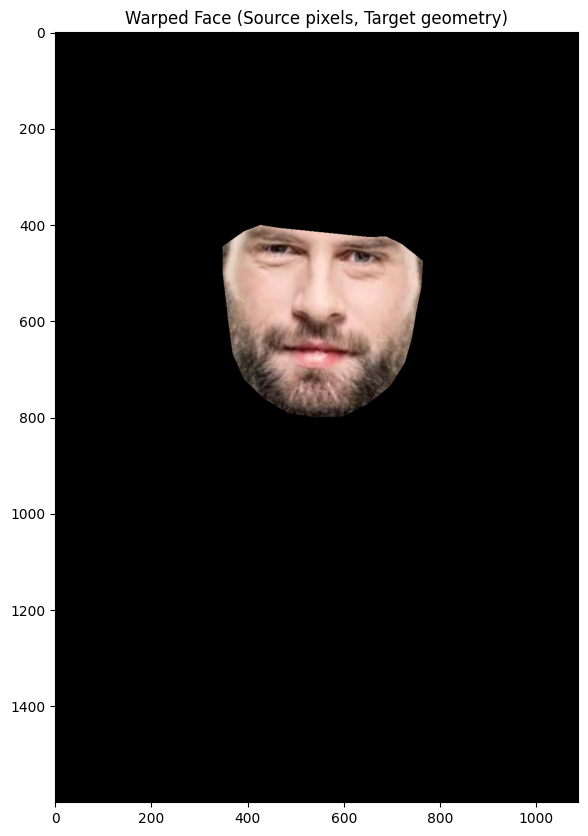

In [55]:
import numpy as np

# Helper function: Applies Affine Transform to a single triangle
def apply_affine_transform(src, src_tri, dst_tri, size):
    # Given a pair of triangles, find the Affine Transform.
    warp_mat = cv2.getAffineTransform(np.float32(src_tri), np.float32(dst_tri))
    
    # Apply the Affine Transform just to the specific patch
    dst = cv2.warpAffine(src, warp_mat, (size[0], size[1]), None, flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    return dst

# 1. Create a blank image (black) to hold the new face
# This will eventually become the "Source Face" forced into the "Target Shape"
img_warped_face = np.zeros_like(img_target)

# 2. Loop through every triangle we found in the previous step
for i, triangle_index in enumerate(tri.simplices):

    # Get the 3 points of the triangle for Source and Target
    tr1_pt1 = points_source[triangle_index[0]]
    tr1_pt2 = points_source[triangle_index[1]]
    tr1_pt3 = points_source[triangle_index[2]]
    
    tr2_pt1 = points_target[triangle_index[0]]
    tr2_pt2 = points_target[triangle_index[1]]
    tr2_pt3 = points_target[triangle_index[2]]

    # --- ROI (Region of Interest) Optimization ---
    # Instead of warping the whole image, we crop a rectangle around the triangle
    
    # Find bounding box for Source Triangle
    rect1 = cv2.boundingRect(np.float32([tr1_pt1, tr1_pt2, tr1_pt3]))
    (x1, y1, w1, h1) = rect1
    
    # Find bounding box for Target Triangle
    rect2 = cv2.boundingRect(np.float32([tr2_pt1, tr2_pt2, tr2_pt3]))
    (x2, y2, w2, h2) = rect2
    
    # Offset points to be relative to the bounding box (start from 0,0)
    tr1_rect = []
    tr2_rect = []
    
    for i in range(3):
        tr1_rect.append(((points_source[triangle_index[i]][0] - x1), (points_source[triangle_index[i]][1] - y1)))
        tr2_rect.append(((points_target[triangle_index[i]][0] - x2), (points_target[triangle_index[i]][1] - y2)))

    # Get the small patch of the image
    img1_rect = img_source[y1:y1+h1, x1:x1+w1]

    # --- The Warp ---
    # Warp the small patch
    size = (w2, h2)
    warped_img_rect = apply_affine_transform(img1_rect, tr1_rect, tr2_rect, size)

    # --- Masking ---
    # We want to insert this triangle into the final image, but only the triangle part (not the box)
    mask = np.zeros((h2, w2, 3), dtype=np.float32)
    cv2.fillConvexPoly(mask, np.int32(tr2_rect), (1.0, 1.0, 1.0), 16, 0)
    
    # Place the warped triangle into the final black image
    img_warped_face[y2:y2+h2, x2:x2+w2] = img_warped_face[y2:y2+h2, x2:x2+w2] * (1 - mask) + warped_img_rect * mask

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img_warped_face.astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title("Warped Face (Source pixels, Target geometry)")
plt.show()

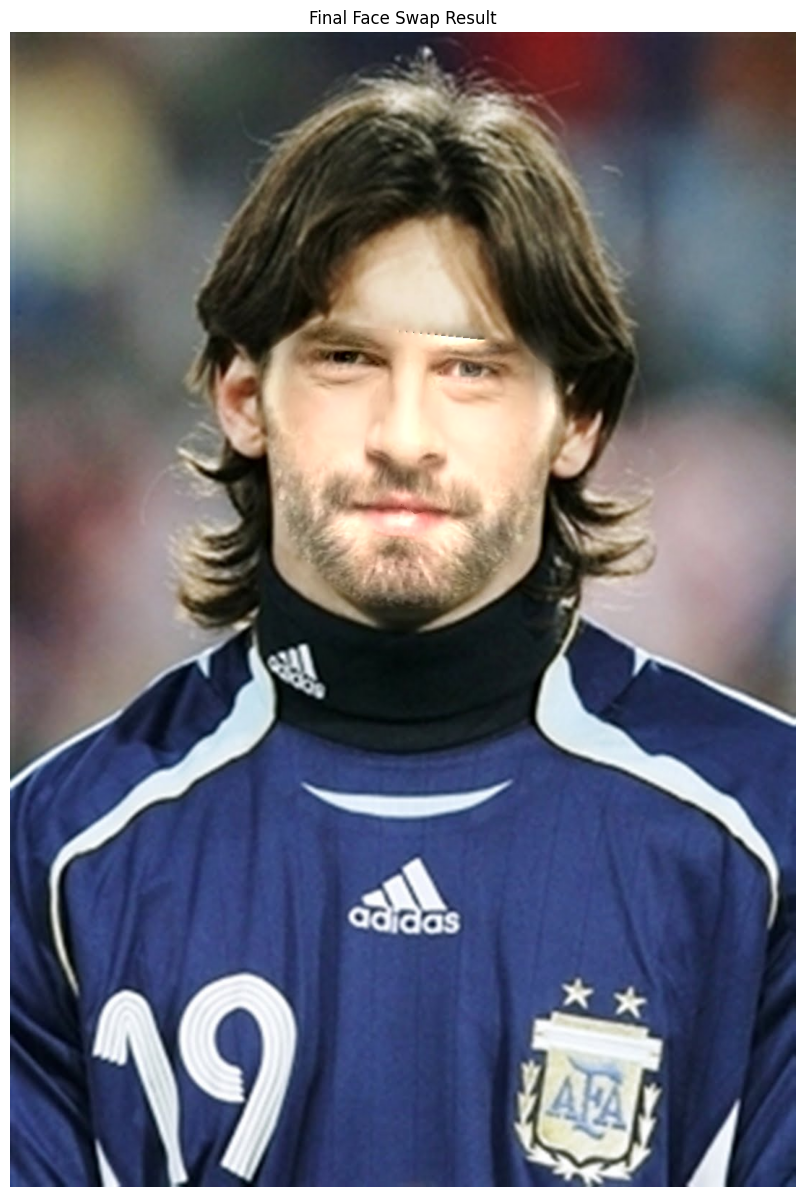

In [56]:
# --- FINAL STEP: SEAMLESS CLONING ---

# 1. Create a Mask for the Face
# We need to tell the computer: "Only paste the face part, not the black background"
mask = np.zeros_like(img_target_gray)
hull_target = []
for i in range(68):
    hull_target.append((landmarks_target.part(i).x, landmarks_target.part(i).y))

hull_target = np.array(hull_target, dtype=np.int32)
# Create a convex hull (the outline of the face)
hull = cv2.convexHull(hull_target)
cv2.fillConvexPoly(mask, hull, 255)

# 2. Find the Center of the Face
# Seamless clone needs to know where the center of the face is
r = cv2.boundingRect(hull)
center = ((r[0] + int(r[2] / 2), r[1] + int(r[3] / 2)))

# 3. Seamless Clone (The Magic Button)
# src: The warped face we just created
# dst: The target image (person B)
# mask: The white shape of the face
output = cv2.seamlessClone(img_warped_face.astype(np.uint8), img_target, mask, center, cv2.NORMAL_CLONE)

# 4. Show the Final Result!
plt.figure(figsize=(15,15))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Final Face Swap Result")
plt.axis('off') # Hide axes for a cleaner look
plt.show()

In [57]:
import os
import cv2
folder_name = "Deepfake_Results"
os.makedirs(folder_name, exist_ok=True)

image1 = IMAGE1.removesuffix('.jpeg')
target_image = TARGET_IMAGE.removesuffix('.jpeg')

file_path = os.path.join(folder_name, f"{image1}_{target_image}_merged.jpeg")
cv2.imwrite(file_path, output)

print(f"Success! Image saved to: {file_path}")

Success! Image saved to: Deepfake_Results/adult_messi_merged.jpeg
